#DSCI-560 Lab 4: Algorithmic Trading Analysis
##Real-Time Stock Price Analysis and Trading Model
###Stock: NVIDIA (NVDA)

This notebook implements:
1. Data collection using yfinance
2. Three trading algorithms (Moving Average, MACD, Hybrid)
3. Mock trading environment
4. Performance metrics (Returns, Sharpe Ratio)

##1. Setup and Data Collection

In [3]:
#Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

#Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print(f"Current date: {datetime.now().strftime('%Y-%m-%d')}")

Current date: 2026-02-07


In [4]:
STOCK_SYMBOL = 'NVDA'
START_DATE = '2023-01-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')
INITIAL_CAPITAL = 100000  #initial investment

print(f"Stock Symbol: {STOCK_SYMBOL}")
print(f"Analysis Period: {START_DATE} to {END_DATE}")
print(f"Initial Capital: ${INITIAL_CAPITAL:,}")

Stock Symbol: NVDA
Analysis Period: 2023-01-01 to 2026-02-07
Initial Capital: $100,000


In [5]:
#Download stock data
print(f"Downloading {STOCK_SYMBOL} data from Yahoo Finance...")
stock_data = yf.download(STOCK_SYMBOL, start=START_DATE, end=END_DATE, progress=False)

#Fix column names - yfinance sometimes returns multi-level columns for single stocks
if isinstance(stock_data.columns, pd.MultiIndex):
    print("Flattening multi-level column names...")
    stock_data.columns = stock_data.columns.get_level_values(0)

#Display basic information
print(f"\nData shape: {stock_data.shape}")
print(f"Date range: {stock_data.index[0]} to {stock_data.index[-1]}")
print(f"\nColumns: {stock_data.columns.tolist()}")
print("\nFirst few rows:")
stock_data.head()

Flattening multi-level column names...

Data shape: (777, 5)
Date range: 2023-01-03 00:00:00 to 2026-02-06 00:00:00

Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

First few rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,14.300683,14.981003,14.081902,14.836147,401277000
2023-01-04,14.734250,14.838146,14.226759,14.552433,431324000
2023-01-05,14.250735,14.549436,14.133852,14.476509,389168000
2023-01-06,14.844141,14.994990,14.019966,14.459526,405044000
2023-01-09,15.612370,16.039942,15.125857,15.268715,504231000


In [6]:
#Data exploration
print("Dataset Information:")
print(stock_data.info())
print("\nBasic Statistics:")
stock_data.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 777 entries, 2023-01-03 to 2026-02-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   777 non-null    float64
 1   High    777 non-null    float64
 2   Low     777 non-null    float64
 3   Open    777 non-null    float64
 4   Volume  777 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 36.4 KB
None

Basic Statistics:


Price,Close,High,Low,Open,Volume
count,777.000000,777.000000,777.000000,777.000000,7.770000e+02
mean,102.186460,103.869462,100.346180,102.221335,3.512677e+08
std,55.127703,55.925137,54.360664,55.270256,1.767753e+08
min,14.250735,14.549436,14.019966,14.459526,6.552850e+07
25%,45.943584,46.828789,45.128890,46.047291,2.070141e+08
50%,110.539764,113.599382,107.374040,110.949862,3.257210e+08
75%,141.194366,143.463972,138.852443,141.951407,4.494050e+08
max,207.028473,212.178195,205.548551,208.068415,1.543911e+09


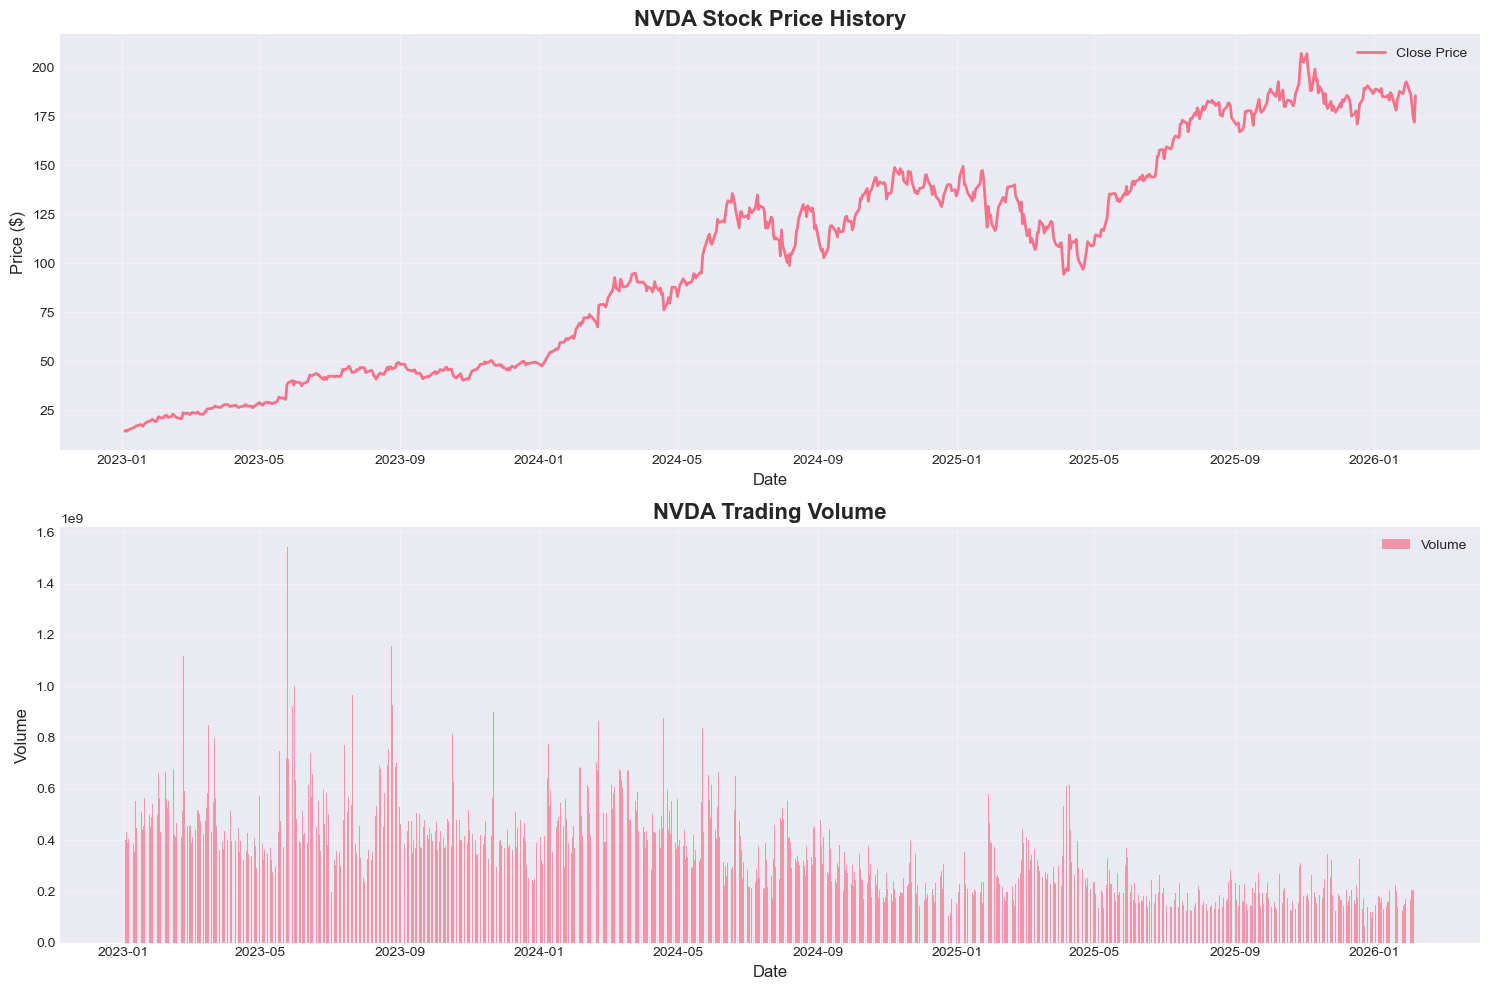

In [7]:
#Visualize stock price history
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

#Price chart
axes[0].plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2)
axes[0].set_title(f'{STOCK_SYMBOL} Stock Price History', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

#Volume chart
axes[1].bar(stock_data.index, stock_data['Volume'], alpha=0.7, label='Volume')
axes[1].set_title(f'{STOCK_SYMBOL} Trading Volume', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##2. Technical Indicators Implementation

In [26]:
def calculate_moving_averages(data, short_window=20, long_window=50):
    df = data.copy()
    df['SMA_Short'] = df['Close'].rolling(window=short_window).mean()
    df['SMA_Long'] = df['Close'].rolling(window=long_window).mean()
    return df

def calculate_ema(data, short_window=12, long_window=26):
    df = data.copy()
    df['EMA_Short'] = df['Close'].ewm(span=short_window, adjust=False).mean()
    df['EMA_Long'] = df['Close'].ewm(span=long_window, adjust=False).mean()
    return df

def calculate_macd(data, fast=12, slow=26, signal=9):
    df = data.copy()
    df['EMA_Fast'] = df['Close'].ewm(span=fast, adjust=False).mean()
    df['EMA_Slow'] = df['Close'].ewm(span=slow, adjust=False).mean()
    df['MACD'] = df['EMA_Fast'] - df['EMA_Slow']
    df['MACD_Signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']
    return df

def calculate_bollinger_bands(data, window=20, num_std=2):
    df = data.copy()
    df['BB_Middle'] = df['Close'].rolling(window=window).mean()
    df['BB_Std'] = df['Close'].rolling(window=window).std()
    df['BB_Upper'] = df['BB_Middle'] + (df['BB_Std'] * num_std)
    df['BB_Lower'] = df['BB_Middle'] - (df['BB_Std'] * num_std)
    return df

#Calculate all indicators (RSI removed)
stock_data = calculate_moving_averages(stock_data)
stock_data = calculate_ema(stock_data)
stock_data = calculate_macd(stock_data)
stock_data = calculate_bollinger_bands(stock_data)

print("Technical indicators calculated")
print("\nAvailable columns:")
print(stock_data.columns.tolist())

Technical indicators calculated

Available columns:
['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_Short', 'SMA_Long', 'EMA_Short', 'EMA_Long', 'EMA_Fast', 'EMA_Slow', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'MA_Signal', 'MA_Position', 'MACD_Signal_Trade', 'MACD_Position', 'Signal_Sum', 'Hybrid_Signal', 'Hybrid_Position']


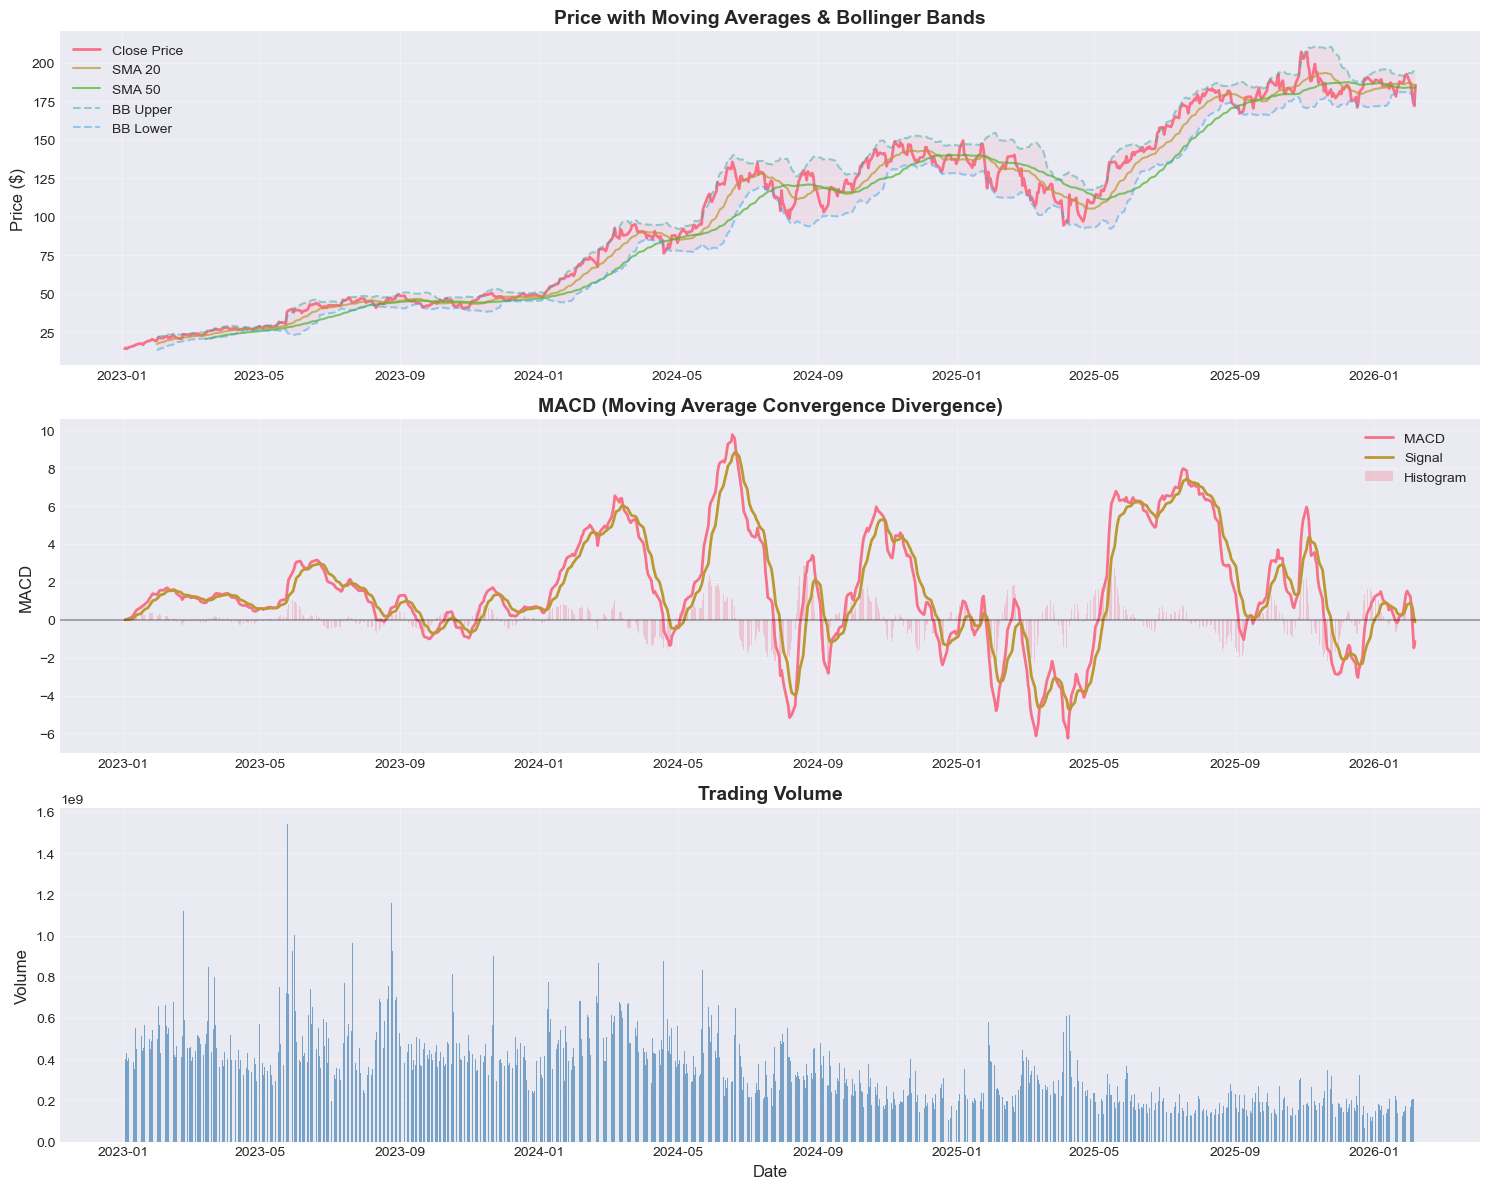

In [9]:
#Visualize technical indicators
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

#Price with Moving Averages and Bollinger Bands
axes[0].plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2)
axes[0].plot(stock_data.index, stock_data['SMA_Short'], label='SMA 20', alpha=0.7)
axes[0].plot(stock_data.index, stock_data['SMA_Long'], label='SMA 50', alpha=0.7)
axes[0].plot(stock_data.index, stock_data['BB_Upper'], label='BB Upper', linestyle='--', alpha=0.5)
axes[0].plot(stock_data.index, stock_data['BB_Lower'], label='BB Lower', linestyle='--', alpha=0.5)
axes[0].fill_between(stock_data.index, stock_data['BB_Lower'], stock_data['BB_Upper'], alpha=0.1)
axes[0].set_title('Price with Moving Averages & Bollinger Bands', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

#MACD
axes[1].plot(stock_data.index, stock_data['MACD'], label='MACD', linewidth=2)
axes[1].plot(stock_data.index, stock_data['MACD_Signal'], label='Signal', linewidth=2)
axes[1].bar(stock_data.index, stock_data['MACD_Histogram'], label='Histogram', alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title('MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MACD', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

#Volume
axes[2].bar(stock_data.index, stock_data['Volume'], alpha=0.7, color='steelblue')
axes[2].set_title('Trading Volume', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Volume', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##3. Trading Algorithms Implementation

###Algorithm 1: Moving Average Crossover Strategy

In [27]:
def moving_average_strategy(data, short_window=20, long_window=50):
    df = data.copy()
    #Initialize signal column
    df['MA_Signal'] = 0
    #Generate signals
    #1 = Buy, -1 = Sell, 0 = Hold
    df.loc[df['SMA_Short'] > df['SMA_Long'], 'MA_Signal'] = 1
    df.loc[df['SMA_Short'] < df['SMA_Long'], 'MA_Signal'] = -1
    #Generate trading positions (when signal changes)
    df['MA_Position'] = df['MA_Signal'].diff()
    return df

stock_data = moving_average_strategy(stock_data)
print("Moving average strategy signals")

Moving average strategy signals


###Algorithm 3: MACD Strategy

In [28]:
def macd_strategy(data):
    df = data.copy()
    #Initialize signal column
    df['MACD_Signal_Trade'] = 0
    #Generate signals
    df.loc[df['MACD'] > df['MACD_Signal'], 'MACD_Signal_Trade'] = 1  #Buy
    df.loc[df['MACD'] < df['MACD_Signal'], 'MACD_Signal_Trade'] = -1  #Sell
    #Generate trading positions
    df['MACD_Position'] = df['MACD_Signal_Trade'].diff()
    return df

stock_data = macd_strategy(stock_data)
print("MACD strategy signals")

MACD strategy signals


###Algorithm 4: Hybrid Strategy (Combined Signals)

In [30]:
def hybrid_strategy(data):
    df = data.copy()
    #Calculate combined signal
    df['Signal_Sum'] = df['MA_Signal'] + df['MACD_Signal_Trade']
    #Initialize hybrid signal
    df['Hybrid_Signal'] = 0
    #Buy when both indicators are positive
    df.loc[df['Signal_Sum'] >= 2, 'Hybrid_Signal'] = 1
    #Sell when sum is negative (either indicator sells)
    df.loc[df['Signal_Sum'] <= 0, 'Hybrid_Signal'] = -1
    #Generate trading positions
    df['Hybrid_Position'] = df['Hybrid_Signal'].diff()
    return df

stock_data = hybrid_strategy(stock_data)
print("Hybrid strategy signals generated ; MA + MACD")
print(f"\nTotal Buy signals(Hybrid): {(stock_data['Hybrid_Position'] == 2).sum()}")
print(f"Total Sell signals(Hybrid): {(stock_data['Hybrid_Position'] == -2).sum()}")

Hybrid strategy signals generated ; MA + MACD

Total Buy signals(Hybrid): 20
Total Sell signals(Hybrid): 20


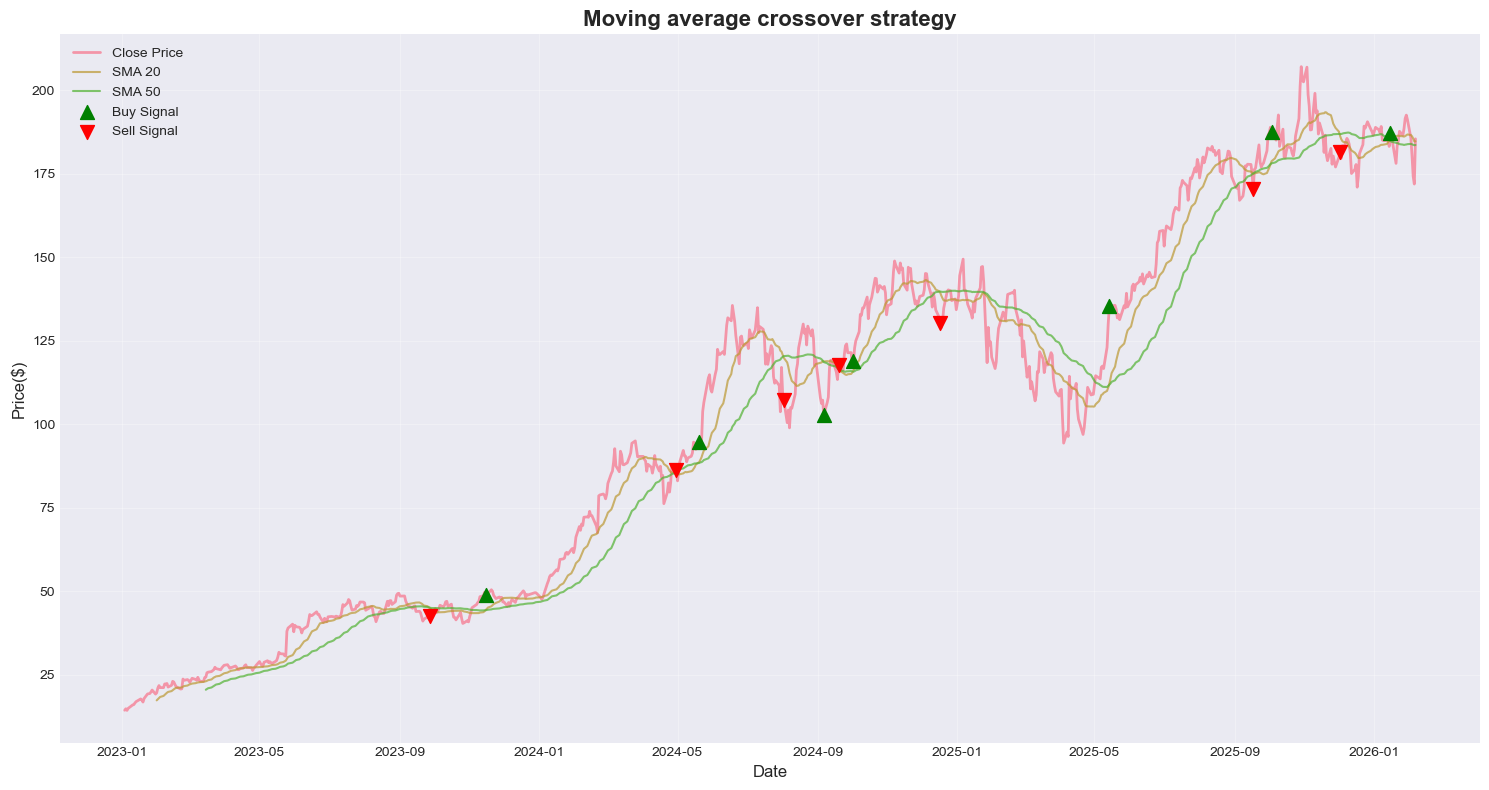

Buy Signals: 7
Sell Signals: 7


In [31]:
#Visualize trading signals for Moving Average strategy
fig, ax = plt.subplots(figsize=(15, 8))

#Plot price and moving averages
ax.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2, alpha=0.7)
ax.plot(stock_data.index, stock_data['SMA_Short'], label='SMA 20', alpha=0.7)
ax.plot(stock_data.index, stock_data['SMA_Long'], label='SMA 50', alpha=0.7)

#Plot buy signals
buy_signals = stock_data[stock_data['MA_Position'] == 2]
ax.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', s=100, label='Buy Signal', zorder=5)

#Plot sell signals
sell_signals = stock_data[stock_data['MA_Position'] == -2]
ax.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', s=100, label='Sell Signal', zorder=5)

ax.set_title('Moving average crossover strategy', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price($)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Buy Signals: {len(buy_signals)}")
print(f"Sell Signals: {len(sell_signals)}")

##4. Mock Trading Environment

In [32]:
class TradingSimulator:
    def __init__(self, initial_capital=100000, commission=0.001):
        self.initial_capital = initial_capital
        self.commission = commission  #0.1% commission per trade
        self.reset()
    
    def reset(self):
        self.cash = self.initial_capital
        self.shares = 0
        self.portfolio_value = []
        self.trades = []
        self.positions = []
        
    def execute_trade(self, date, price, signal, shares_to_trade=None):
        if signal == 2:  #Buy signal
            #Use all available cash to buy shares
            if shares_to_trade is None:
                shares_to_trade = int(self.cash / (price * (1 + self.commission)))
            
            if shares_to_trade > 0:
                cost = shares_to_trade * price * (1 + self.commission)
                if cost <= self.cash:
                    self.cash -= cost
                    self.shares += shares_to_trade
                    self.trades.append({
                        'Date': date,
                        'Type': 'BUY',
                        'Price': price,
                        'Shares': shares_to_trade,
                        'Cost': cost,
                        'Cash': self.cash,
                        'Total_Shares': self.shares
                    })
                    
        elif signal == -2:  #Sell signal
            #Sell all shares
            if shares_to_trade is None:
                shares_to_trade = self.shares
            
            if shares_to_trade > 0 and shares_to_trade <= self.shares:
                revenue = shares_to_trade * price * (1 - self.commission)
                self.cash += revenue
                self.shares -= shares_to_trade
                self.trades.append({
                    'Date': date,
                    'Type': 'SELL',
                    'Price': price,
                    'Shares': shares_to_trade,
                    'Revenue': revenue,
                    'Cash': self.cash,
                    'Total_Shares': self.shares
                })
    
    def update_portfolio(self, date, price):
        total_value = self.cash + (self.shares * price)
        self.portfolio_value.append({
            'Date': date,
            'Cash': self.cash,
            'Shares': self.shares,
            'Stock_Value': self.shares * price,
            'Total_Value': total_value
        })
        
    def run_backtest(self, data, signal_column='Hybrid_Position'):
        self.reset()
        
        for index, row in data.iterrows():
            #Execute trades based on signals
            if not pd.isna(row[signal_column]):
                self.execute_trade(index, row['Close'], row[signal_column])
            
            #Update portfolio value
            self.update_portfolio(index, row['Close'])
        
        return pd.DataFrame(self.portfolio_value), pd.DataFrame(self.trades)

print("TradingSimulator")

TradingSimulator


In [37]:
#Run backtests for all strategies
strategies = {
    'Moving Average': 'MA_Position',
    'MACD': 'MACD_Position',
    'Hybrid': 'Hybrid_Position'
}

results = {}
trades_log = {}

for strategy_name, signal_col in strategies.items():
    print(f"\nRunning backtest for {strategy_name} Strategy...")
    simulator = TradingSimulator(initial_capital=INITIAL_CAPITAL)
    portfolio_df, trades_df = simulator.run_backtest(stock_data, signal_column=signal_col)
    results[strategy_name] = portfolio_df
    trades_log[strategy_name] = trades_df
    print(f"Total trades: {len(trades_df)}")
    print(f"Final portfolio value: ${portfolio_df['Total_Value'].iloc[-1]:,.2f}")


Running backtest for Moving Average Strategy...
Total trades: 13
Final portfolio value: $299,567.04

Running backtest for MACD Strategy...
Total trades: 58
Final portfolio value: $226,636.91

Running backtest for Hybrid Strategy...
Total trades: 40
Final portfolio value: $270,805.67


In [35]:
#Display trade history for Hybrid strategy
if len(trades_log['Hybrid']) > 0:
    trades_log['Hybrid']

##5. Performance Metrics

In [36]:
def calculate_performance_metrics(portfolio_df, initial_capital, risk_free_rate=0.02):
    #Total return
    final_value = portfolio_df['Total_Value'].iloc[-1]
    total_return = (final_value - initial_capital) / initial_capital
    
    #Annualized return
    days = len(portfolio_df)
    years = days / 252  #Trading days in a year
    annualized_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    
    #Calculate daily returns
    portfolio_df['Returns'] = portfolio_df['Total_Value'].pct_change()
    
    #Volatility (annualized)
    volatility = portfolio_df['Returns'].std() * np.sqrt(252)
    
    #Sharpe Ratio
    excess_returns = annualized_return - risk_free_rate
    sharpe_ratio = excess_returns / volatility if volatility != 0 else 0
    
    #Maximum Drawdown
    cumulative_returns = (1 + portfolio_df['Returns']).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    
    #Win rate (if trades available)
    win_rate = None
    
    metrics = {
        'Initial Capital': initial_capital,
        'Final Value': final_value,
        'Total Return(%)': total_return * 100,
        'Annualized Return(%)': annualized_return * 100,
        'Volatility(%)': volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown(%)': max_drawdown * 100,
        'Trading Days': days
    }
    
    return metrics

#Calculate metrics for all strategies
performance_metrics = {}
for strategy_name, portfolio_df in results.items():
    metrics = calculate_performance_metrics(portfolio_df, INITIAL_CAPITAL)
    performance_metrics[strategy_name] = metrics

#Create comparison dataframe
metrics_df = pd.DataFrame(performance_metrics).T
print("metrics comparision")
metrics_df

metrics comparision


,Initial Capital,Final Value,Total Return(%),Annualized Return(%),Volatility(%),Sharpe Ratio,Max Drawdown(%),Trading Days
Moving Average,100000.0,299567.039414,199.567039,42.737670,30.772213,1.323846,-23.482873,777.0
MACD,100000.0,226636.908915,126.636909,30.389425,32.736114,0.867220,-42.373363,777.0
Hybrid,100000.0,270805.667379,170.805667,38.140630,25.576863,1.413020,-17.352737,777.0


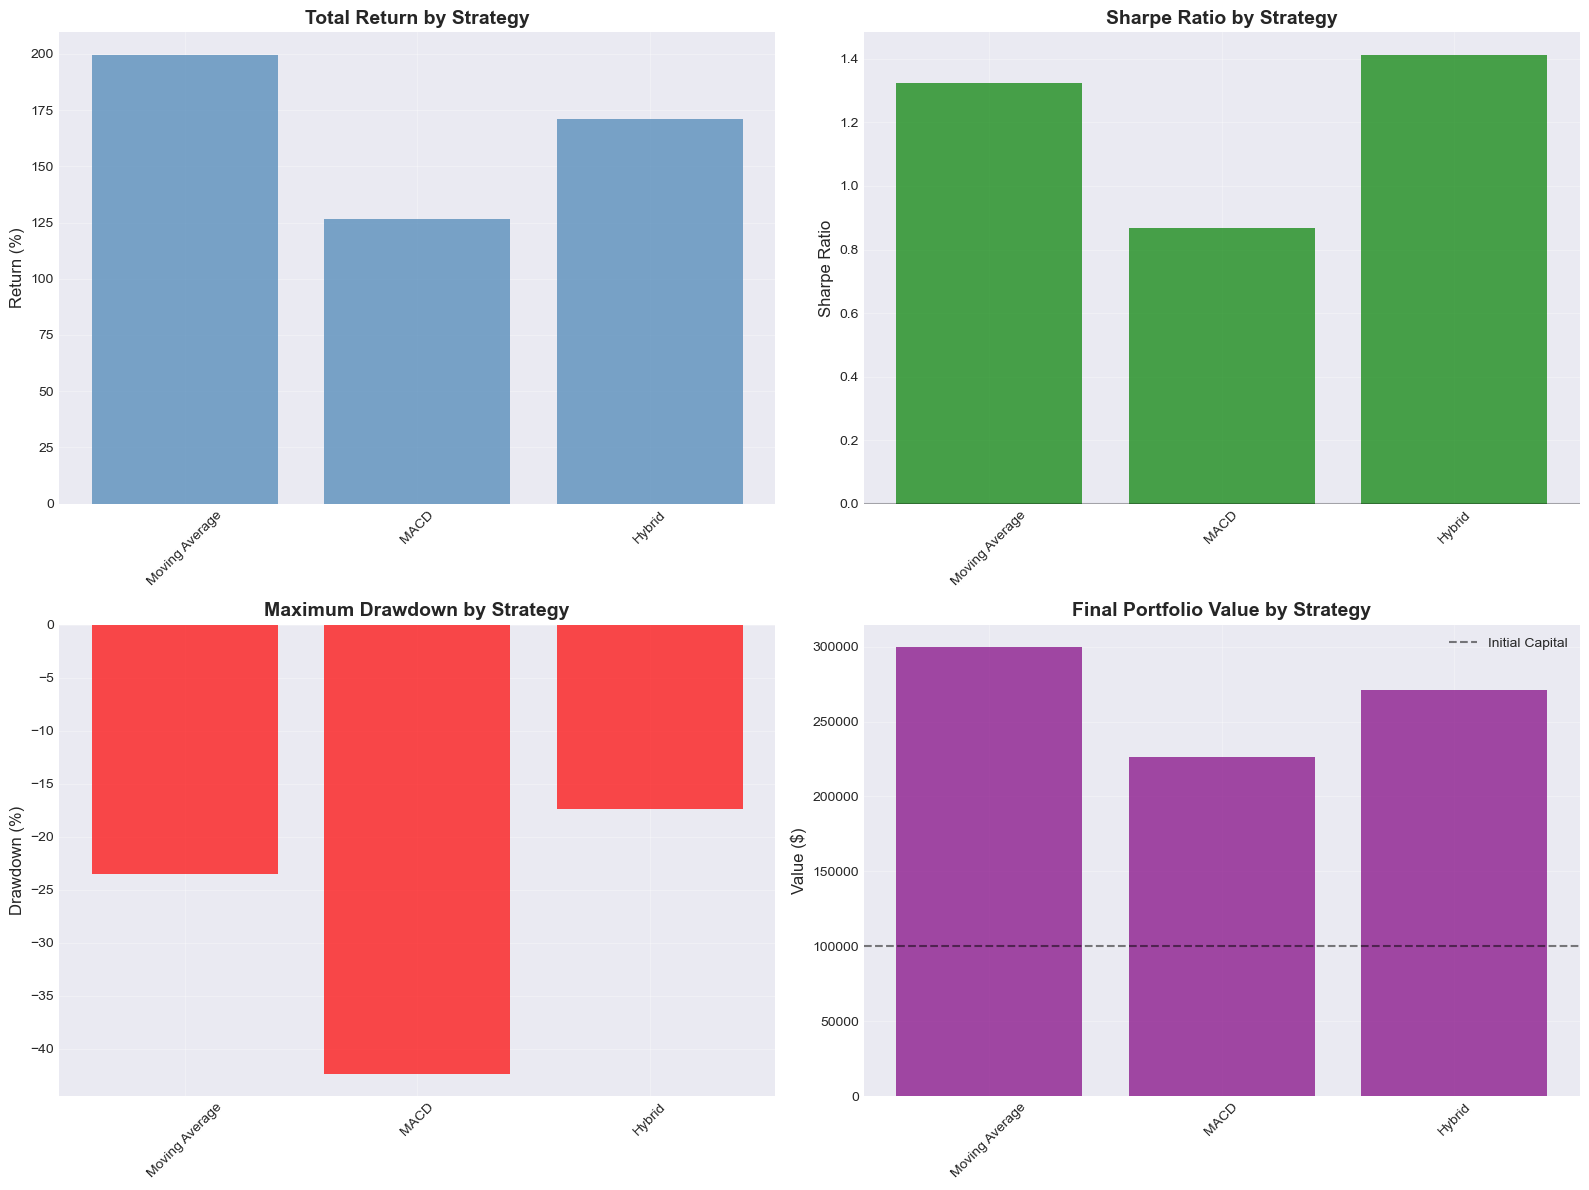

In [18]:
#Visualize performance metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Total Return
axes[0, 0].bar(metrics_df.index, metrics_df['Total Return (%)'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Total Return by Strategy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Return (%)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

#Sharpe Ratio
axes[0, 1].bar(metrics_df.index, metrics_df['Sharpe Ratio'], color='green', alpha=0.7)
axes[0, 1].set_title('Sharpe Ratio by Strategy', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Sharpe Ratio', fontsize=12)
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

#Max Drawdown
axes[1, 0].bar(metrics_df.index, metrics_df['Max Drawdown (%)'], color='red', alpha=0.7)
axes[1, 0].set_title('Maximum Drawdown by Strategy', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Drawdown (%)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

#Final Portfolio Value
axes[1, 1].bar(metrics_df.index, metrics_df['Final Value'], color='purple', alpha=0.7)
axes[1, 1].set_title('Final Portfolio Value by Strategy', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Value ($)', fontsize=12)
axes[1, 1].axhline(y=INITIAL_CAPITAL, color='black', linestyle='--', 
                   label='Initial Capital', alpha=0.5)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

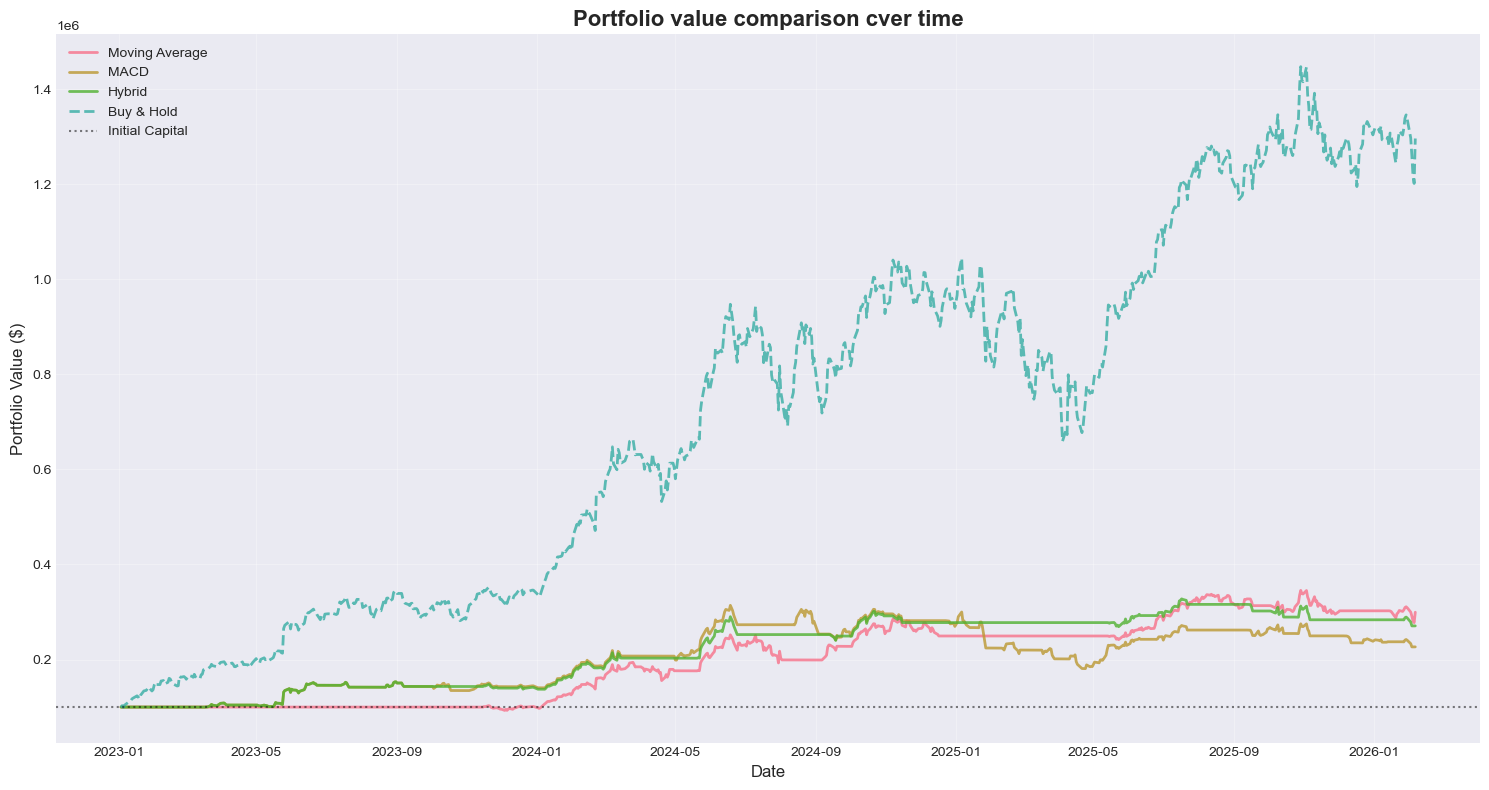

In [38]:
#Portfolio value over time comparison
fig, ax = plt.subplots(figsize=(15, 8))

for strategy_name, portfolio_df in results.items():
    ax.plot(portfolio_df['Date'], portfolio_df['Total_Value'], 
            label=strategy_name, linewidth=2, alpha=0.8)

#Add Buy & Hold strategy for comparison
buy_hold_simulator = TradingSimulator(initial_capital=INITIAL_CAPITAL)
first_price = stock_data['Close'].iloc[0]
shares_bought = int(INITIAL_CAPITAL / first_price)
buy_hold_value = [shares_bought * price for price in stock_data['Close']]
ax.plot(stock_data.index, buy_hold_value, 
        label='Buy & Hold', linewidth=2, linestyle='--', alpha=0.8)

ax.axhline(y=INITIAL_CAPITAL, color='black', linestyle=':', 
           label='Initial Capital', alpha=0.5)
ax.set_title('Portfolio value comparison cver time', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value ($)', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##6. Strategy Analysis & Summary

In [23]:
print("KEY FINDINGS:")
print("The Hybrid Strategy combines MA and MACD indicators")
print("   to provide robust trading signals with strong confirmation.")
print("Higher Sharpe Ratio indicates better risk-adjusted returns.")
print("Maximum Drawdown shows the largest peak-to-trough decline,")
print("   indicating the risk of the strategy.")
print("Consider transaction costs and slippage in real-world trading.")

KEY FINDINGS:
The Hybrid Strategy combines MA and MACD indicators
   to provide robust trading signals with strong confirmation.
Higher Sharpe Ratio indicates better risk-adjusted returns.
Maximum Drawdown shows the largest peak-to-trough decline,
   indicating the risk of the strategy.
Consider transaction costs and slippage in real-world trading.


##7. Export Results

In [21]:
#Export results to CSV files
import os

#Create results directory
results_dir = 'trading_results'
os.makedirs(results_dir, exist_ok=True)

#Export performance metrics
metrics_df.to_csv(f'{results_dir}/performance_metrics.csv')
print(f"Performance metrics saved to {results_dir}/performance_metrics.csv")

#Export trade logs for each strategy
for strategy_name, trades_df in trades_log.items():
    if len(trades_df) > 0:
        filename = f'{results_dir}/{strategy_name.lower().replace(" ", "_")}_trades.csv'
        trades_df.to_csv(filename, index=False)
        print(f"{strategy_name} trades saved to {filename}")

#Export portfolio values
for strategy_name, portfolio_df in results.items():
    filename = f'{results_dir}/{strategy_name.lower().replace(" ", "_")}_portfolio.csv'
    portfolio_df.to_csv(filename, index=False)
    print(f"{strategy_name} portfolio saved to {filename}")

#Export stock data with indicators
stock_data.to_csv(f'{results_dir}/stock_data_with_indicators.csv')
print(f"Stock data with indicators saved to {results_dir}/stock_data_with_indicators.csv")

print("\nAll results exported successfully!")

Performance metrics saved to trading_results/performance_metrics.csv
Moving Average trades saved to trading_results/moving_average_trades.csv
MACD trades saved to trading_results/macd_trades.csv
Hybrid trades saved to trading_results/hybrid_trades.csv
Moving Average portfolio saved to trading_results/moving_average_portfolio.csv
MACD portfolio saved to trading_results/macd_portfolio.csv
Hybrid portfolio saved to trading_results/hybrid_portfolio.csv
Stock data with indicators saved to trading_results/stock_data_with_indicators.csv

All results exported successfully!
